new deformed j_list:
[1, 16, -94, 976, -9598, 95056, -940894, 9313936, -92198398, 912670096, -9034502494, 89432354896, -885289046398, 8763458109136, -86749292044894, 858729462339856, -8500545331353598, 84146723851196176, -832966693180608094, 8245520207954884816, -81622235386368239998, 807976833655727515216, -7998146101170906912094, 79173484178053341605776, -783736695679362509145598, 7758193472615571749850256, -76798198030476354989356894, 760223786832147978143718736, -7525439670291003426447830398, 74494172916077886286334585296, -737416289490487859436898022494, 7299668721988800708082645639696, -72259270930397519221389558374398, 715293040581986391505812938104336, -7080671134889466395836739822668894, 70091418308312677566861585288584656, -693833511948237309272779113063177598, 6868243701174060415160929545343191376, -67988603499792366842336516340368736094, 673017791296749608008204233858344169616, -6662189309467703713239705822243072959998, 65948875303380287524388853988572385430416, -6528265637

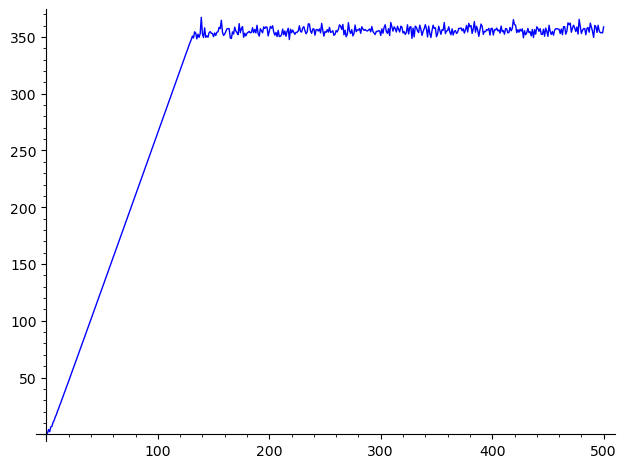

In [2]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

import matplotlib.pyplot as plt
import numpy as np

def signsNoGraphics(f, center, searchradius, grain):
    inc = searchradius / grain
    dta = []

    black = (0, 0, 0)
    green = (0, 1, 0)
    blue = (0, 0, 1)
    red = (1, 0, 0)
    yellow = (1, 1, 0)

    k = -searchradius - inc
    while k < searchradius:
        row = []
        j = -searchradius - inc
        while j < searchradius:
            w = CC(center + j + k * I)
            fw = f(w)
            u = real_part(fw)
            v = imag_part(fw)

            if u >= 0:
                if v >= 0:
                    shade = blue
                else:
                    shade = green
            else:
                if v >= 0:
                    shade = red
                else:
                    shade = yellow

            row.append(shade)
            j += inc
        dta.append(row)
        k += inc

    return dta

def plot_signs(dta):
    img = np.array(dta, dtype=float)
    plt.figure(figsize=(8, 8))
    plt.imshow(img, origin='lower', interpolation='nearest')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


h_list=[n**4 for n in range(1,521)]
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("new deformed j_list:")
print(deformed_j_list[:50])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
    if n<21:
            print("n:",n)
            print("chi:")
            print(chi)
    
p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()


chi_list_a=chi_list[:300]
chi_list_b=chi_list[301:400]
chi_list_c=chi_list[401:450]
chi_list_d=chi_list[450:480]
chi_list_e=chi_list[481:500]

with open('/Users/barrybrent/data2/run22may26no9.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run22may26no10.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run22may26no11.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run22may26no12.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run22may26no12a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)
with open('/Users/barrybrent/data2/run22may26no12b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)
with open('/Users/barrybrent/data2/run22may26no12c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)
with open('/Users/barrybrent/data2/run22may26no12d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)
with open('/Users/barrybrent/data2/run22may26no12e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)